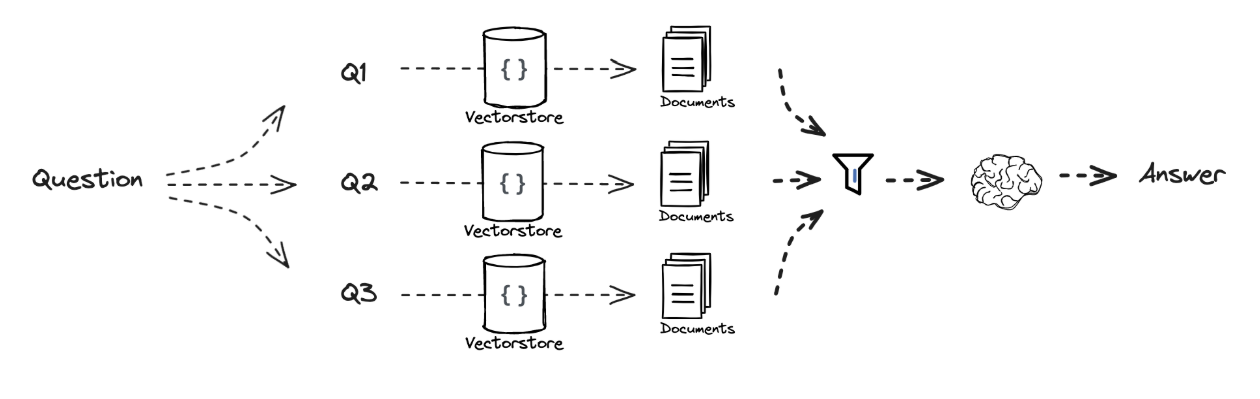

In [1]:
import bs4
import os
from langchain_community.document_loaders import WebBaseLoader
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("ADV_RAG_KEY")

loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()
blog_docs

USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [2]:
# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=300, 
    chunk_overlap=50)

# Make splits
splits = text_splitter.split_documents(blog_docs)
splits, "", len(splits)

([Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and ref

In [3]:
vectorstore = Chroma.from_documents(documents=splits, 
                                    embedding=GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001"))

retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 4, "fetch_k": 20, "lambda_mult": 0.5}
)
retriever 

VectorStoreRetriever(tags=['Chroma', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x0000023FFEB71050>, search_type='mmr', search_kwargs={'k': 4, 'fetch_k': 20, 'lambda_mult': 0.5})

In [4]:
retriever.invoke("What is task decomposition?")

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.\nTree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process can be BFS (breadth-first search) or DFS (depth-first search) with each state evaluated by a

In [5]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import (
    RunnableLambda,
    RunnableParallel,
    RunnablePassthrough,
)
from langchain_google_genai import ChatGoogleGenerativeAI


llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0, api_key=api_key)
llm

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', temperature=0.0, client=<google.genai.client.Client object at 0x0000023FFE733490>, default_metadata=(), model_kwargs={})

## RAG Fusion

In [6]:
multi_query_prompt = ChatPromptTemplate.from_template("""
You are an AI assistant.

Generate 5 different rephrasings of the user's question
for semantic search retrieval.

Return only the questions separated by newlines.

Original question:
{question}
""")

generate_queries = (
    multi_query_prompt
    | llm
    | StrOutputParser()
    | RunnableLambda(lambda x: x.split("\n"))
)

In [7]:
generate_queries.invoke("What is task decomposition for LLM agents?")

['How do LLM agents utilize task decomposition?',
 'Explain the concept of breaking down tasks for agents powered by large language models.',
 'What is the purpose of task decomposition in the context of LLM-based AI agents?',
 'How do large language model agents approach the decomposition of complex tasks?',
 'Define task modularization for AI agents that leverage LLMs.']

In [8]:
retrieve_docs = generate_queries | retriever.map()
retrieve_docs.invoke("What is task decomposition for LLM agents?")

[[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.\nTree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process can be BFS (breadth-first search) or DFS (depth-first search) with each state evaluated by 

## Reciprocal Rank Fusion (RRF)

In [9]:
from collections import defaultdict

def reciprocal_rank_fusion(results, k=60):
    fused_scores = defaultdict(float)

    for docs in results:
        for rank, doc in enumerate(docs):
            fused_scores[doc.page_content] += 1 / (rank + k)

    reranked_results = sorted(
        fused_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return reranked_results

In [10]:
fusion_chain = retrieve_docs | RunnableLambda(reciprocal_rank_fusion)

In [13]:
fusion_chain.invoke("What is task decomposition for LLM agents?")

[('Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.\nTree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process can be BFS (breadth-first search) or DFS (depth-first search) with each state evaluated by a classifier (via a prompt) or majority vote.\nTask decomposition can be done (1) by LLM with simpl

In [14]:
def format_docs(docs):
    top_docs = docs[:5]  # Adjust the number as needed
    return "\n\n".join(doc for doc, score in top_docs)

In [15]:
rag_prompt = ChatPromptTemplate.from_template("""
Answer the question based only on the context below.

Context:
{context}

Question:
{question}
""")

final_rag_chain = (
    RunnableParallel({
        "context": fusion_chain | RunnableLambda(format_docs),
        "question": RunnablePassthrough(),
    })
    | rag_prompt
    | llm
    | StrOutputParser()
)

response = final_rag_chain.invoke(
    "What is task decomposition for LLM agents?"
)

print(response)

Task decomposition for LLM agents is the process of breaking down complicated or hard tasks into smaller, simpler, and more manageable steps or sub-tasks. This technique enhances model performance on complex tasks by allowing the LLM to "think step by step" and utilize more test-time computation.

Methods for task decomposition mentioned in the context include:
*   **Chain of Thought (CoT):** Instructing the model to "think step by step" to transform big tasks into multiple manageable ones.
*   **Tree of Thoughts (ToT):** An extension of CoT that explores multiple reasoning possibilities at each step, decomposing a problem into multiple thought steps and generating multiple thoughts per step, creating a tree structure.
*   **LLM with simple prompting:** Using prompts like "Steps for XYZ.\n1." or "What are the subgoals for achieving XYZ?".
*   **Task-specific instructions:** Providing specific guidance, e.g., "Write a story outline."
*   **Human inputs.**

In the HuggingGPT workflow, th